### Generate the six figures used in the pedagogical document.
Each figure isolates one new physical effect, building cumulatively:
- **fig1**: Euclidean standard candle (hard cutoff)
- **fig2**: Euclidean + log-normal LF
- **fig3**: + cosmology (DM=1000z, flat LCDM)
- **fig4**: + SFR(z) weighting (Madau-Dickinson)
- **fig5**: + intra-channel DM smearing $S_{min} \sim \sqrt{1+(DM/1000)^2}$
- **fig6**: + spectral index alpha (K-correction)

In [1]:
# Canonical imports, cosmology, and unit-safe calibration (paste whole cell)
import numpy as np
from scipy.integrate import cumulative_trapezoid
from scipy.special import erfc
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 11,
    "axes.titlesize": 11.5,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
})

# --- Telescopes / aperture ---
D_ASKAP = 12.0  # m (reference aperture used for Smin calibration)
telescopes = [("D0", 12.0,  "tab:blue"),
              ("5D0", 60.0,  "tab:orange"),
              ("25D0", 300.0, "tab:green")]

# --- Unit constants (canonical) ---
JY = 1e-26            # W m^-2 Hz^-1 per Jy
MPC_TO_M = 3.0857e22  # meters per Mpc
MPC_TO_KPC = 1e3      # kpc per Mpc
DEG2_TO_SR = (np.pi/180.0)**2

# ---------------------------------------------------------------------------
# Cosmology (used from fig3 onwards) — MATCHED TO MC NOTEBOOK
# ---------------------------------------------------------------------------
# Use FlatLambdaCDM with same parameters as MC notebook
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

z_grid = np.linspace(1e-4, 8.0, 8001)
DC = cosmo.comoving_distance(z_grid).to_value(u.Mpc)
dVc_dz = cosmo.differential_comoving_volume(z_grid).to_value(u.Mpc**3 / u.sr) * (4.0 * np.pi)
DM_grid_cosmo = 1000.0 * z_grid   # DM proxy used in this pedagogical notebook

# ---------------------------------------------------------------------------
# Radiometry calibration (single canonical Smin in Jy)
# ---------------------------------------------------------------------------
# Keep your ASKAP calibration in Jy; scale by aperture area ~ D^2
Smin_ASKAP_Jy = 13.1   # Jy (calibrated reference)
def Smin_Jy(D):
    """Smin in Jy for aperture diameter D (m); single source of truth."""
    return Smin_ASKAP_Jy * (D_ASKAP / D)**2

def Smin_SI(D):
    """Smin in SI units (W m^-2 Hz^-1)."""
    return Smin_Jy(D) * JY

# Compute a characteristic L_star expressed in the same units as the Schechter grid (Jy·kpc^2)
# Use luminosity distance at z=1: d_L = DC(z=1) * (1+z)
DC_h_Mpc = np.interp(1.0, z_grid, DC)             # Mpc
dL_kpc_z1 = DC_h_Mpc * MPC_TO_KPC * (1.0 + 1.0)   # kpc

L_star_jy_kpc2 = Smin_Jy(D_ASKAP) * (dL_kpc_z1**2)
print(f"Characteristic L_star (Jy·kpc^2): {L_star_jy_kpc2:.3e}")    
# Small numeric / modelling constants
sigma = 1.0 / np.sqrt(2)

# SFR weighting (Madau–Dickinson 2014)
def psi(z): return 0.015 * (1+z)**2.7 / (1 + ((1+z)/2.9)**5.6)
w_SFR = psi(z_grid) / psi(0.0)

Characteristic L_star (Jy·kpc^2): 5.720e+14


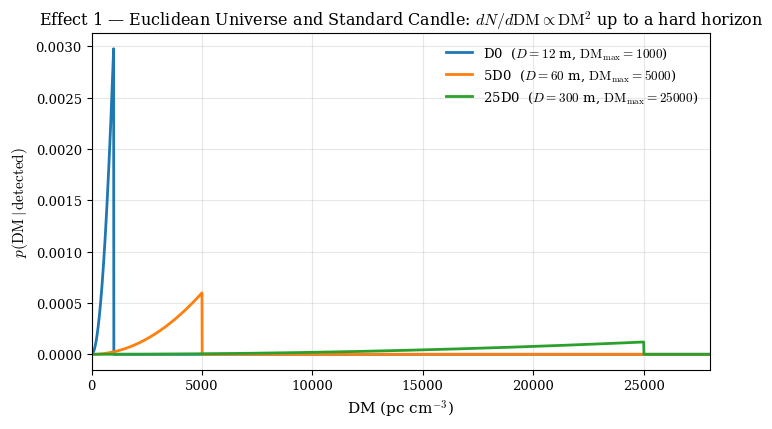

In [2]:
# ---------------------------------------------------------------------------
# Figure 1: Euclidean standard candle  (hard horizon, no LF spread)
# ---------------------------------------------------------------------------
# In Euclidean limit, calibrate so ASKAP horizon DM_max(ASKAP) = 1000.
# Standard-candle d_max(D) ∝ D (sensitivity gain), and DM ∝ d.
# Therefore DM_max(D) = 1000 (D/D_ASKAP).
DM_grid_eucl = np.linspace(0, 30000, 6001)

fig, ax = plt.subplots(figsize=(7.3, 4.4))
for name, D, col in telescopes:
    DM_max = 1000.0 * (D / D_ASKAP)
    pdf = np.where(DM_grid_eucl <= DM_max, DM_grid_eucl**2, 0.0)
    norm = np.trapz(pdf, DM_grid_eucl)
    ax.plot(DM_grid_eucl, pdf/norm, color=col, lw=2,
            label=fr"{name}  ($D={D:g}$ m, $\mathrm{{DM}}_{{\max}}={DM_max:.0f}$)")
ax.set_xlim(0, 28000)
ax.set_xlabel(r"DM (pc cm$^{-3}$)")
ax.set_ylabel(r"$p(\mathrm{DM}\,|\,\mathrm{detected})$")
ax.set_title(r"Effect 1 — Euclidean Universe and Standard Candle: $dN/d\mathrm{DM}\propto \mathrm{DM}^2$ up to a hard horizon")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()

plt.show()

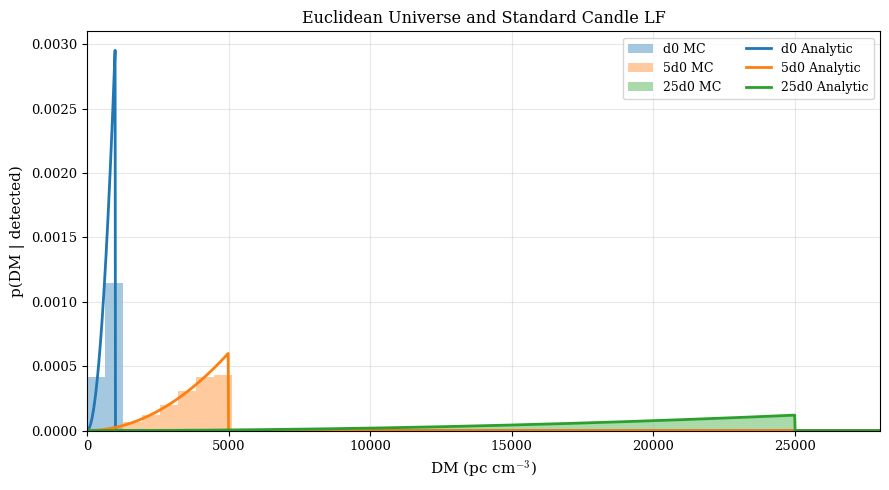

In [3]:
# For Effect 1 comparison (lines ~107-157)
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load MC pickle you just saved
with open("../mc_all_results_euc_std.pkl", "rb") as f:
    mc = pickle.load(f)

# Map keys -> apertures used by your MC notebook
mc_key_to_D = {"d0": 12.0, "5d0": 60.0, "25d0": 300.0}
D_ASKAP = 12.0

# Effect 1 analytic pdf: DM^2 up to DM_max = 1000 * (D/D_ASKAP)
def effect1_pdf(D, DM_grid):
    DM_max = 1000.0 * (D / D_ASKAP)
    pdf = np.where(DM_grid <= DM_max, DM_grid**2, 0.0)
    return pdf / np.trapz(pdf, DM_grid)

# Prepare common bins from MC data
all_dms = []
for k in mc:
    all_dms.extend([r["DM"] for r in mc[k]])
dm_min = min(all_dms) if all_dms else 0.0
dm_max = max(all_dms) if all_dms else 28000.0
common_bins = np.linspace(dm_min, min(dm_max, 28000.0), 40)

DM_grid = np.linspace(0, 28000, 2000)
fig, ax = plt.subplots(figsize=(9,5))

colors = {"d0":"tab:blue","5d0":"tab:orange","25d0":"tab:green"}

# STEP 1: Plot all MC histograms first
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key])==0:
        continue
    res = mc[key]
    DMs = np.array([r["DM"] for r in res])
    pops = np.array([r["n_total_population"] for r in res])
    # MC weighted PDF histogram (density=True to compare shapes)
    ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.4,
            color=colors.get(key,"C0"), label=f"{key} MC")

# STEP 2: Plot all analytical curves
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key])==0:
        continue
    # Effect-1 analytic curve for same aperture
    ax.plot(DM_grid, effect1_pdf(D, DM_grid), color=colors.get(key,"C0"),
            lw=2.0, label=f"{key} Analytic")

ax.set_xlim(0, 28000)
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("p(DM | detected)")
ax.set_title('Euclidean Universe and Standard Candle LF')
ax.legend(ncol=2, fontsize=9, frameon=True)  # Two columns
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Cosmology helpers: smear + Lmin_cosmo + pdet_cosmo + pdf_DM (unit-consistent)
def get_smear_factor(z, D):
    z = np.asarray(z)
    DM = 1000.0 * z
    return np.sqrt(1.0 + (DM / 1000.0)**2)

def Lmin_cosmo(z, D, alpha=0.0, smear=False, k_correction=False):
    """
    k_correction=False: matches MC (only apply K-correction if alpha != 0)
    k_correction=True:  pedagogical (always apply (1+z)^(-1-alpha))
    """
    z_arr = np.asarray(z)
    DC_Mpc = np.interp(z_arr, z_grid, DC)
    dL_kpc = DC_Mpc * MPC_TO_KPC * (1.0 + z_arr)
    s = get_smear_factor(z_arr, D) if smear else 1.0
    
    if k_correction or alpha != 0.0:
        k_corr = (1.0 + z_arr)**(-1.0 - alpha)
    else:
        k_corr = 1.0
    
    Lmin = Smin_Jy(D) * (dL_kpc**2) * k_corr * s
    return Lmin


In [5]:
# ==========================================
# Schechter Luminosity Function setup
# ==========================================
# Schechter Luminosity Function (L* tied to radiometric calibration)\

L_STAR_SCH = L_star_jy_kpc2
ALPHA_SCH = -1.5
L_MIN_SCH = 1e10       # Jy kpc^2
L_MAX_SCH = 1e16      # Jy kpc^2

def schechter_function(L, L_prime, alpha, phi_star=1.0):
    x = L / L_prime
    return phi_star * x**alpha * np.exp(-x)

# Pre-compute the CDF using the Jy·kpc^2 grid
L_grid_sch = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 5000)
phi_grid_sch = schechter_function(L_grid_sch, L_STAR_SCH, ALPHA_SCH)
from scipy.integrate import cumulative_trapezoid
cdf_sch = cumulative_trapezoid(phi_grid_sch, L_grid_sch, initial=0)
cdf_sch /= cdf_sch[-1]  # Normalize to 1.0    # Jy kpc^2

def schechter_function(L, L_prime, alpha, phi_star=1.0):
    x = L / L_prime
    return phi_star * x**alpha * np.exp(-x)

# Pre-compute the CDF using the Jy kpc^2 grid
L_grid_sch = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 5000)
phi_grid_sch = schechter_function(L_grid_sch, L_STAR_SCH, ALPHA_SCH)
from scipy.integrate import cumulative_trapezoid
cdf_sch = cumulative_trapezoid(phi_grid_sch, L_grid_sch, initial=0)
cdf_sch /= cdf_sch[-1]  # Normalize to 1.0


def get_schechter_detection_fraction(L_min_array, local_L_star=None):
    """
    Return fraction brighter than L_min using precomputed (L_grid_sch, cdf_sch).
    Backwards-compatible: if local_L_star is provided, treat L_min_array as in
    the same units as local_L_star and scale into the Schechter units.
    Otherwise L_min_array is assumed to already be in Jy·kpc^2.
    """
    Lm = np.array(L_min_array, copy=False)
    if local_L_star is not None:
        scale = L_STAR_SCH / local_L_star
        Lm = Lm * scale
    cdf_vals = np.interp(Lm, L_grid_sch, cdf_sch, left=0.0, right=1.0)
    return 1.0 - cdf_vals


def pdet_cosmo(z, D, alpha=0.0, smear=False):
    """Detection fraction as a function of z (scalar or array). Returns values in [0,1]."""
    Lm = Lmin_cosmo(z, D, alpha, smear)
    return get_schechter_detection_fraction(Lm)

def pdf_DM(D, sfr=False, alpha=0.0, smear=False):
    """
    Normalized p(DM | detected) using dVc_dz and DM_grid_cosmo.
    - DM_grid_cosmo = 1000 * z_grid is the DM proxy (pc cm^-3)
    """
    pd = pdet_cosmo(z_grid, D, alpha, smear)              # fraction per z
    f  = (1.0 / 1000.0) * (1.0 / (1.0 + z_grid)) * dVc_dz * pd
    if sfr:
        f = f * w_SFR
    # Normalize over DM_grid_cosmo (which is 1000*z_grid)
    return f / np.trapz(f, DM_grid_cosmo)

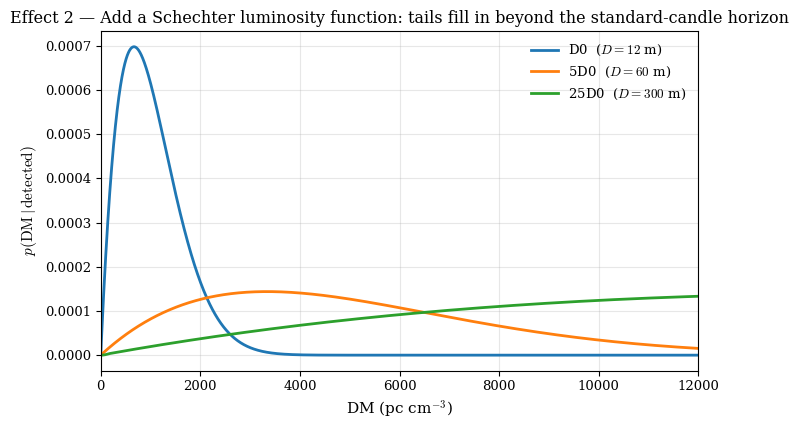

In [6]:
def pdet_eucl(DM_array, D):
    DM = np.asarray(DM_array)
    H0_km_s_Mpc = 70.0  # or use Planck18 value
    DH_Mpc = 299792.458 / H0_km_s_Mpc
    z = DM / 1000.0
    d_kpc = DH_Mpc * z * 1000.0  # Use actual Hubble distance
    L_min = (d_kpc**2) * Smin_Jy(D)
    return get_schechter_detection_fraction(L_min)

fig, ax = plt.subplots(figsize=(7.3, 4.4))
DM_e = np.linspace(0.5, 12000, 4001)
for name, D, col in telescopes:
    pdf = DM_e**2 * pdet_eucl(DM_e, D)
    pdf /= np.trapz(pdf, DM_e)
    ax.plot(DM_e, pdf, color=col, lw=2, label=fr"{name}  ($D={D:g}$ m)")
ax.set_xlim(0, 12000)
ax.set_xlabel(r"DM (pc cm$^{-3}$)")
ax.set_ylabel(r"$p(\mathrm{DM}\,|\,\mathrm{detected})$")
ax.set_title(r"Effect 2 — Add a Schechter luminosity function: tails fill in beyond the standard-candle horizon")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

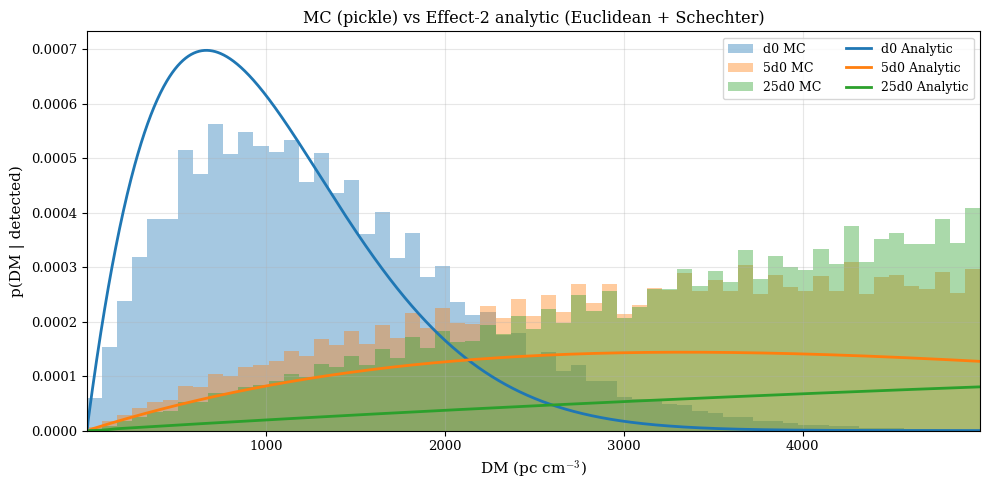

In [7]:
# Plot MC (pickle) vs Effect-2 analytic (Euclidean + Schechter)
from pathlib import Path

pkl = Path("/home/thsu/FRB_population/mc_all_results_ecu_sch.pkl")
if not pkl.exists():
    raise FileNotFoundError(f"Cannot find {pkl}. Make sure mc_all_results_euc_sch.pkl is saved in the parent directory.")

with open(pkl, "rb") as f:
    mc = pickle.load(f)

mc_key_to_D = {"d0": 12.0, "5d0": 60.0, "25d0": 300.0}
colors = {"d0": "tab:blue", "5d0": "tab:orange", "25d0": "tab:green"}

# Build common bins from MC
all_dms = [r["DM"] for k in mc for r in mc[k]] if mc else []
dm_min = 0.5 if all_dms else 0.0
dm_max = min(max(all_dms) if all_dms else 12000.0, 12000.0)
common_bins = np.linspace(dm_min, dm_max, 60)

DM_grid = np.linspace(0.5, 12000, 4001)

fig, ax = plt.subplots(figsize=(10, 5))

# STEP 1: Plot all MC histograms first
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key]) == 0:
        continue
    
    res = mc[key]
    DMs = np.array([r["DM"] for r in res])
    pops = np.array([r["n_total_population"] for r in res])
    
    # MC weighted histogram (density=True to compare shapes)
    ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.4,
            color=colors.get(key), label=f"{key} MC")

# STEP 2: Plot all analytical curves
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key]) == 0:
        continue
    
    # Effect-2 analytic: Euclidean + Schechter (no SFR, no smear)
    pdf = DM_grid**2 * pdet_eucl(DM_grid, D)
    pdf /= np.trapz(pdf, DM_grid)
    ax.plot(DM_grid, pdf, color=colors.get(key), lw=2.0, label=f"{key} Analytic")

ax.set_xlim(dm_min, min(dm_max, 12000))
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("p(DM | detected)")
ax.set_title("MC (pickle) vs Effect‑2 analytic (Euclidean + Schechter)")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

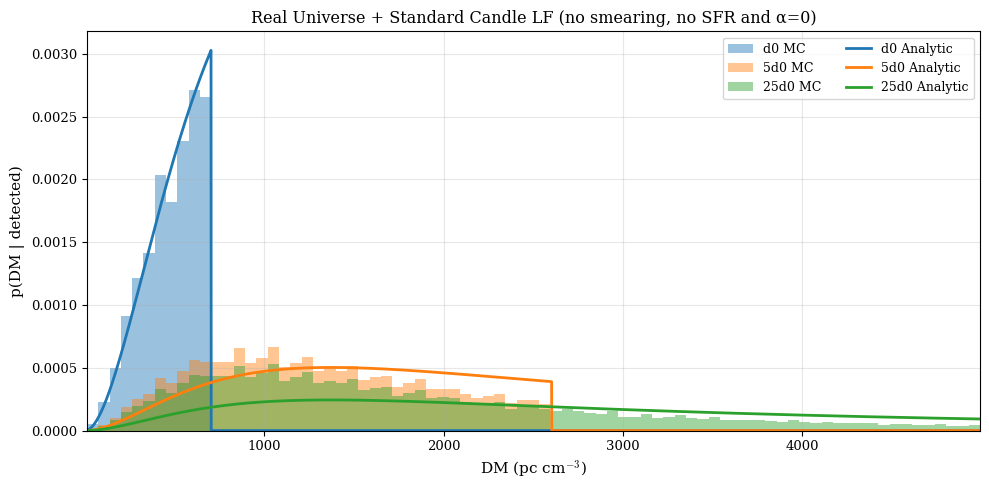

In [8]:
# Plot MC (pickle) vs analytic curve for cosmology + standard candle LF
import pickle
from pathlib import Path

# Load MC pickle
pkl = Path("/home/thsu/FRB_population/mc_all_results_cos_std.pkl")
if not pkl.exists():
    raise FileNotFoundError(f"Cannot find {pkl}")

with open(pkl, "rb") as f:
    mc = pickle.load(f)

mc_key_to_D = {"d0": 12.0, "5d0": 60.0, "25d0": 300.0}
colors = {"d0": "tab:blue", "5d0": "tab:orange", "25d0": "tab:green"}

# Standard candle luminosity (use canonical calibration, same as pedagogical figures)
L_std = 2.4e14  # Jy·kpc^2

def pdet_std_cosmo(z, D):
    """
    Detection fraction for standard candle in cosmology.
    Returns 1 if L_std >= L_min(z,D), else 0.
    """
    Lm = Lmin_cosmo(z, D, alpha=0.0, smear=False, k_correction=False)
    return np.where(L_std >= Lm, 1.0, 0.0)

def pdf_DM_std_cosmo(D):
    """
    Normalized p(DM | detected) for cosmology + standard candle.
    Uses real dVc/dz from cosmology, no SFR weighting.
    """
    pd = pdet_std_cosmo(z_grid, D)
    f = (1.0 / 1000.0) * (1.0 / (1.0 + z_grid)) * dVc_dz * pd
    norm = np.trapz(f, DM_grid_cosmo)
    if norm > 0:
        return f / norm
    else:
        return np.zeros_like(f)

# Build common bins from MC data
all_dms = [r["DM"] for k in mc for r in mc[k]] if mc else []
dm_min = 0.0 if not all_dms else min(all_dms)
dm_max = 6000.0 if not all_dms else min(max(all_dms), 6000.0)
common_bins = np.linspace(dm_min, dm_max, 80)

fig, ax = plt.subplots(figsize=(10, 5))
DM_plot = DM_grid_cosmo

# STEP 1: Plot all MC histograms first
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key]) == 0:
        continue
    
    res = mc[key]
    DMs = np.array([r["DM"] for r in res])
    pops = np.array([r["n_total_population"] for r in res])
    
    # MC weighted histogram
    ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.45,
            color=colors.get(key), label=f"{key} MC")

# STEP 2: Plot all analytical curves
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key]) == 0:
        continue
    
    # Analytic curve: cosmology + standard candle
    p_std = pdf_DM_std_cosmo(D)
    ax.plot(DM_plot, p_std, color=colors.get(key), lw=2.0, label=f"{key} Analytic")

ax.set_xlim(dm_min, min(dm_max, 10000))
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("p(DM | detected)")
ax.set_title("Real Universe + Standard Candle LF (no smearing, no SFR and α=0)")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

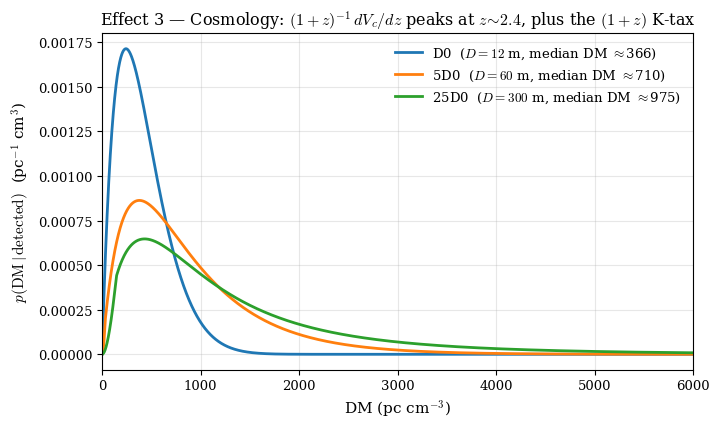

In [9]:
# --- Figure 3: cosmology (constant Phi_0, alpha=0) ---
fig, ax = plt.subplots(figsize=(7.3, 4.4))
for name, D, col in telescopes:
    p = pdf_DM(D, sfr=False, alpha=0.0)
    cdf = cumulative_trapezoid(p, DM_grid_cosmo, initial=0)
    med = np.interp(0.5, cdf, DM_grid_cosmo)
    ax.plot(DM_grid_cosmo, p, color=col, lw=2,
            label=fr"{name}  ($D={D:g}$ m, median DM $\approx${med:.0f})")
ax.set_xlim(0, 6000)
ax.set_xlabel(r"DM (pc cm$^{-3}$)")
ax.set_ylabel(r"$p(\mathrm{DM}\,|\,\mathrm{detected})$  (pc$^{-1}$ cm$^3$)")
ax.set_title(r"Effect 3 — Cosmology: $(1+z)^{-1}\,dV_c/dz$ peaks at $z\!\sim\!2.4$, plus the $(1+z)$ K-tax")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

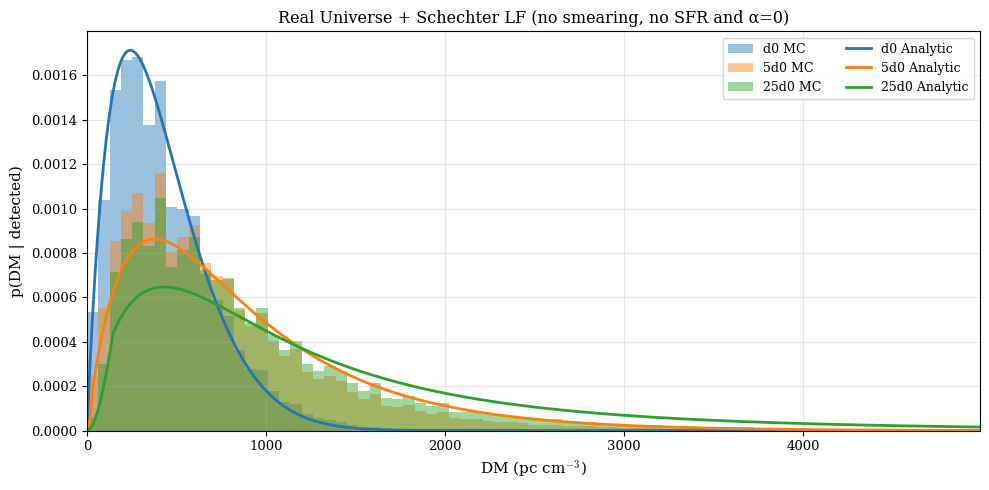

In [10]:
# Plot MC (pickle) vs Effect-3 analytic (cosmology α=0)
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

pkl = Path("/home/thsu/FRB_population/mc_all_results_cos_sch.pkl")
if not pkl.exists():
    raise FileNotFoundError(pkl)

with open(pkl, "rb") as f:
    mc = pickle.load(f)

mc_key_to_D = {"d0": 12.0, "5d0": 60.0, "25d0": 300.0}
colors = {"d0":"tab:blue","5d0":"tab:orange","25d0":"tab:green"}

# Ensure pdf_DM and DM_grid_cosmo are defined (run earlier cells)
try:
    _ = pdf_DM
    _ = DM_grid_cosmo
except NameError:
    raise RuntimeError("Run the notebook cells that define pdf_DM and DM_grid_cosmo first.")

# Build common bins from MC
all_dms = [r["DM"] for k in mc for r in mc[k]] if mc else []
dm_min = 0.0
dm_max = min(max(all_dms) if all_dms else 6000.0, 30000.0)
common_bins = np.linspace(dm_min, dm_max, 80)

fig, ax = plt.subplots(figsize=(10,5))
DM_plot = DM_grid_cosmo

# STEP 1: Plot all MC histograms first
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key])==0:
        continue
    res = mc[key]
    DMs = np.array([r["DM"] for r in res])
    pops = np.array([r["n_total_population"] for r in res])
    ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.45,
            color=colors.get(key), label=f"{key} MC")

# STEP 2: Plot all analytical curves
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key])==0:
        continue
    # Effect‑3 analytic: cosmology only (no SFR, no smear, alpha=0)
    p3 = pdf_DM(D, sfr=False, alpha=0.0, smear=False)
    ax.plot(DM_plot, p3, color=colors.get(key), lw=2.0, label=f"{key} Analytic")

ax.set_xlim(dm_min, min(dm_max, 28000))
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("p(DM | detected)")
ax.set_title("Real Universe + Schechter LF (no smearing, no SFR and α=0)")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

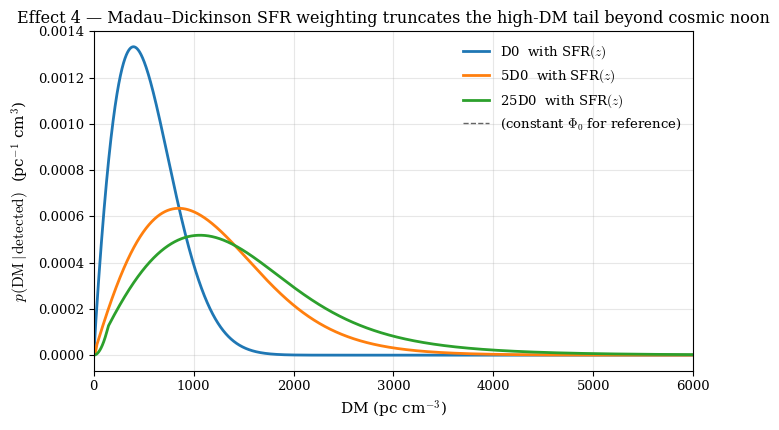

In [11]:
# --- Figure 4: + SFR weighting ---
fig, ax = plt.subplots(figsize=(7.3, 4.4))
for name, D, col in telescopes:
    p_no  = pdf_DM(D, sfr=False, alpha=0.0)
    p_sfr = pdf_DM(D, sfr=True,  alpha=0.0)
    # ax.plot(DM_grid_cosmo, p_no,  color=col, lw=1.0, ls="--", alpha=0.6)
    ax.plot(DM_grid_cosmo, p_sfr, color=col, lw=2.0,
            label=fr"{name}  with SFR$(z)$")
ax.plot([], [], 'k--', lw=1, alpha=0.6, label="(constant $\\Phi_0$ for reference)")
ax.set_xlim(0, 6000)
ax.set_xlabel(r"DM (pc cm$^{-3}$)")
ax.set_ylabel(r"$p(\mathrm{DM}\,|\,\mathrm{detected})$  (pc$^{-1}$ cm$^3$)")
ax.set_title(r"Effect 4 — Madau–Dickinson SFR weighting truncates the high-DM tail beyond cosmic noon")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

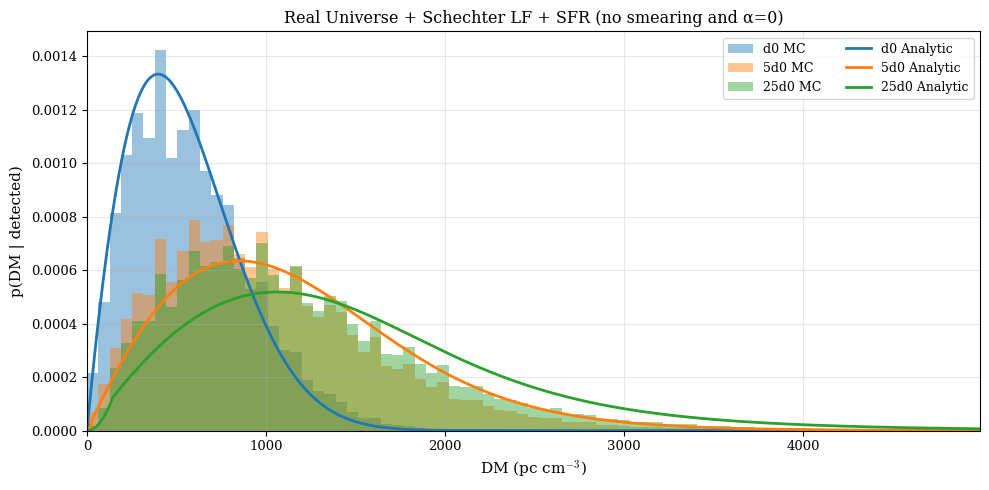

In [12]:
# Plot MC (pickle) vs Effect-4 analytic (SFR weighting)
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

pkl = Path("/home/thsu/FRB_population/mc_all_results_cos_sfr_sch.pkl")
if not pkl.exists():
    raise FileNotFoundError(pkl)

with open(pkl, "rb") as f:
    mc = pickle.load(f)

mc_key_to_D = {"d0": 12.0, "5d0": 60.0, "25d0": 300.0}
colors = {"d0":"tab:blue","5d0":"tab:orange","25d0":"tab:green"}

# Ensure pdf_DM and DM_grid_cosmo are defined (run earlier cells)
try:
    _ = pdf_DM
    _ = DM_grid_cosmo
except NameError:
    raise RuntimeError("Run the notebook cells that define pdf_DM and DM_grid_cosmo first.")

# Build common bins from MC
all_dms = [r["DM"] for k in mc for r in mc[k]] if mc else []
dm_min = 0.0
dm_max = min(max(all_dms) if all_dms else 6000.0, 30000.0)
common_bins = np.linspace(dm_min, dm_max, 80)

fig, ax = plt.subplots(figsize=(10,5))
DM_plot = DM_grid_cosmo

# STEP 1: Plot all MC histograms first
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key])==0:
        continue
    res = mc[key]
    DMs = np.array([r["DM"] for r in res])
    pops = np.array([r["n_total_population"] for r in res])
    ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.45,
            color=colors.get(key), label=f"{key} MC")

# STEP 2: Plot all analytical curves
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key])==0:
        continue
    # Effect-4 analytic: SFR weighting on (sfr=True), no smearing, alpha=0
    p4 = pdf_DM(D, sfr=True, alpha=0.0, smear=False)
    ax.plot(DM_plot, p4, color=colors.get(key), lw=2.0, label=f"{key} Analytic")

ax.set_xlim(dm_min, min(dm_max, 28000))
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("p(DM | detected)")
ax.set_title('Real Universe + Schechter LF + SFR (no smearing and α=0)')
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

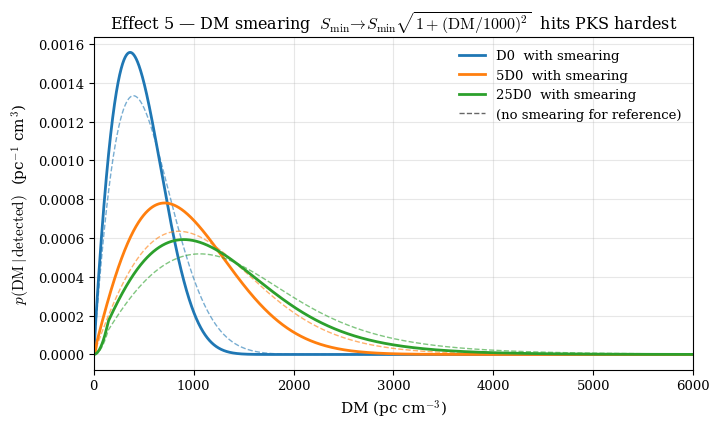

In [13]:
# --- Figure 5: + DM smearing (on top of SFR) -----------------------------
fig, ax = plt.subplots(figsize=(7.3, 4.4))
for name, D, col in telescopes:
    p_no = pdf_DM(D, sfr=True, alpha=0.0, smear=False)
    p_sm = pdf_DM(D, sfr=True, alpha=0.0, smear=True)
    ax.plot(DM_grid_cosmo, p_no, color=col, lw=1.0, ls="--", alpha=0.6)
    ax.plot(DM_grid_cosmo, p_sm, color=col, lw=2.0,
            label=fr"{name}  with smearing")
ax.plot([], [], 'k--', lw=1, alpha=0.6, label="(no smearing for reference)")
ax.set_xlim(0, 6000)
ax.set_xlabel(r"DM (pc cm$^{-3}$)")
ax.set_ylabel(r"$p(\mathrm{DM}\,|\,\mathrm{detected})$  (pc$^{-1}$ cm$^3$)")
ax.set_title(r"Effect 5 — DM smearing  $S_\min\!\to\! S_\min\sqrt{1+(\mathrm{DM}/1000)^2}$  hits PKS hardest")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

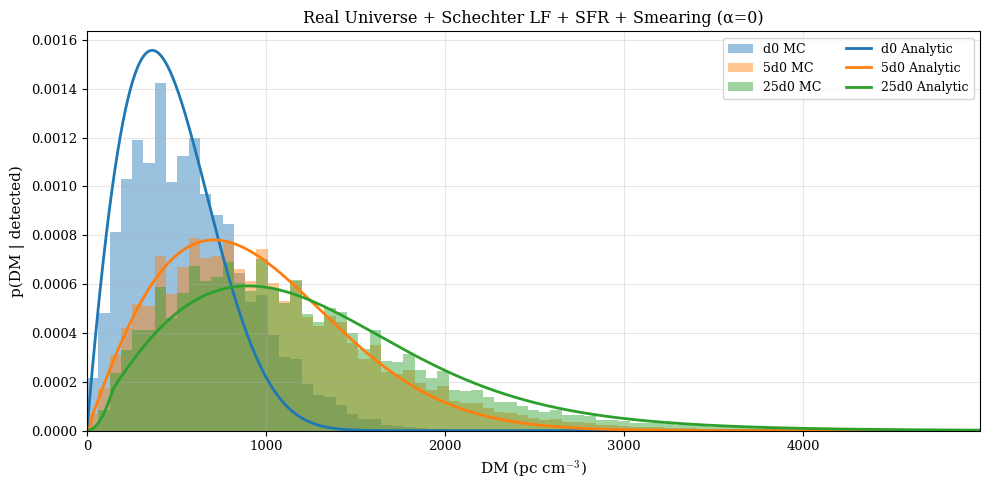

In [14]:
# Paste this into a notebook cell (run earlier cells that define pdf_DM and DM_grid_cosmo first)
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

pkl = Path("/home/thsu/FRB_population/mc_all_results_cos_sfr_sch_smear.pkl")
if not pkl.exists():
    raise FileNotFoundError(pkl)

with open(pkl, "rb") as f:
    mc = pickle.load(f)

mc_key_to_D = {"d0": 12.0, "5d0": 60.0, "25d0": 300.0}
colors = {"d0":"tab:blue","5d0":"tab:orange","25d0":"tab:green"}

# Ensure analytic helpers exist
try:
    _ = pdf_DM
    _ = DM_grid_cosmo
except NameError:
    raise RuntimeError("Run the notebook cells that define pdf_DM and DM_grid_cosmo first (canonical imports + calibration).")

# Common histogram bins from MC
all_dms = [r["DM"] for k in mc for r in mc[k]] if mc else []
dm_min = 0.0
dm_max = min(max(all_dms) if all_dms else 6000.0, 30000.0)
common_bins = np.linspace(dm_min, dm_max, 80)

fig, ax = plt.subplots(figsize=(10,5))
DM_plot = DM_grid_cosmo

# STEP 1: Plot all MC histograms first
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key]) == 0:
        continue
    res = mc[key]
    DMs = np.array([r["DM"] for r in res])
    pops = np.array([r["n_total_population"] for r in res])
    ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.45,
            color=colors.get(key), label=f"{key} MC")

# STEP 2: Plot all analytical curves
for key, D in mc_key_to_D.items():
    if key not in mc or len(mc[key]) == 0:
        continue
    # Effect-5 analytic: sfr=True, smear=True, alpha=0.0
    p5 = pdf_DM(D, sfr=True, alpha=0.0, smear=True)
    ax.plot(DM_plot, p5, color=colors.get(key), lw=2.0, label=f"{key} Analytic")

ax.set_xlim(dm_min, min(dm_max, 28000))
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("p(DM | detected)")
ax.set_title("Real Universe + Schechter LF + SFR + Smearing (α=0)")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

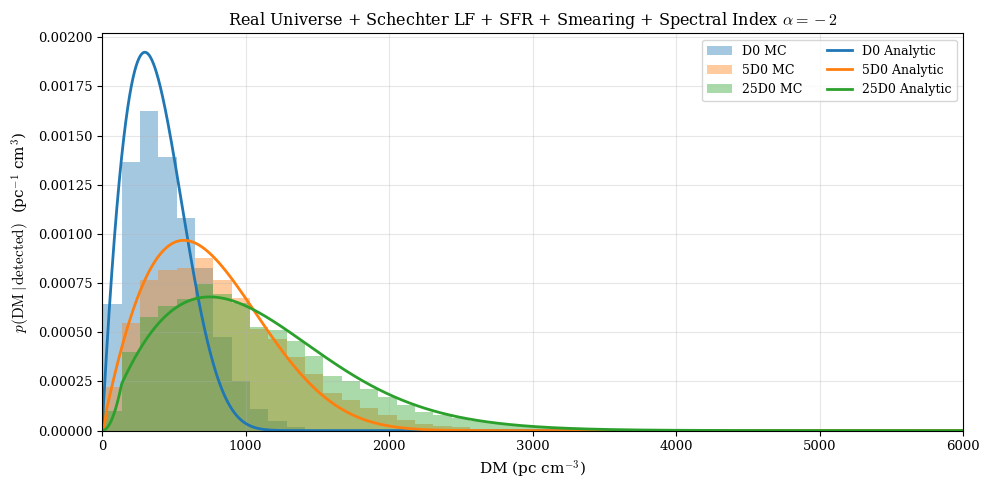

In [15]:
import pickle
import numpy as np

# Load MC data
try:
    with open("../mc_all_results_alpha_minus_2.pkl", "rb") as f:
        mc_results = pickle.load(f)
except FileNotFoundError:
    mc_results = None

# --- Figure 6: + spectral index alpha (on top of SFR + smearing) ---------
fig, ax = plt.subplots(figsize=(10,5))

# Mapping from telescope names here to MC data keys
mc_key_map = {"D0": "d0", "5D0": "5d0", "25D0": "25d0"}

if mc_results is not None:
    # Find common bins for histograms
    all_dms = []
    for k in mc_results:
        all_dms.extend([r['DM'] for r in mc_results[k]])
    if all_dms:
        dm_min = min(all_dms)
        dm_max = max(all_dms)
        common_bins = np.linspace(dm_min, dm_max, 40)
    else:
        # fallback: fixed bin edges covering the plotting range
        common_bins = np.linspace(0.0, 6000.0, 40)

# STEP 1: Plot all MC histograms first
for name, D, col in telescopes:
    if mc_results is not None and mc_key_map[name] in mc_results:
        res = mc_results[mc_key_map[name]]
        if len(res) > 0:
            DMs = np.array([r['DM'] for r in res])
            pops = np.array([r['n_total_population'] for r in res])
            ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.4,
                    color=col, label=f"{name} MC")

# STEP 2: Plot all analytical curves
for name, D, col in telescopes:
    pa = pdf_DM(D, sfr=True, alpha=-2.0, smear=True)
    ax.plot(DM_grid_cosmo, pa, color=col, lw=2.0,
            label=f"{name} Analytic")

ax.set_xlim(0, 6000)
ax.set_xlabel(r"DM (pc cm$^{-3}$)")
ax.set_ylabel(r"$p(\mathrm{DM}\,|\,\mathrm{detected})$  (pc$^{-1}$ cm$^3$)")
ax.set_title(r"Real Universe + Schechter LF + SFR + Smearing + Spectral Index $\alpha=-2$")
ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

In [16]:
# Target: DM=1000 -> z=1 in this notebook convention
z_t = 1.0
D0 = 12.0

# Your current physics settings for Figure 6
alpha_t = -2.0
smear_t = True

Lmin_t = Lmin_cosmo(z_t, D0, alpha=alpha_t, smear=smear_t)
print("Lmin at DM=1000 (z=1) for D0 =", Lmin_t)

Lmin at DM=1000 (z=1) for D0 = 1617749731979554.0
